In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("/content/Unicorn_Companies.xlsx")

In [4]:
df.head()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


In [5]:
df.tail()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
1069,Zhaogang,$1B,2017-06-29,E-commerce & direct-to-consumer,Shanghai,China,Asia,2012,$379M,"K2 Ventures, Matrix Partners China, IDG Capital"
1070,Zhuan Zhuan,$1B,2017-04-18,E-commerce & direct-to-consumer,Beijing,China,Asia,2015,$990M,"58.com, Tencent Holdings"
1071,Zihaiguo,$1B,2021-05-06,Consumer & retail,Chongqing,China,Asia,2018,$80M,"Xingwang Investment Management, China Capital ..."
1072,Zopa,$1B,2021-10-19,Fintech,London,United Kingdom,Europe,2005,$792M,"IAG Capital Partners, Augmentum Fintech, North..."
1073,Zwift,$1B,2020-09-16,E-commerce & direct-to-consumer,Long Beach,United States,North America,2014,$620M,"Novator Partners, True, Causeway Media Partners"


In [6]:
print("The Shape of the Dataset:",df.shape)

The Shape of the Dataset: (1074, 10)


In [7]:
print("No. of Rows in the dateset:",df.shape[1])

No. of Rows in the dateset: 10


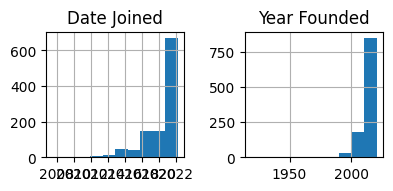

In [9]:
df.hist(bins=10,layout=(6,5),figsize=(10,10))
plt.tight_layout()
plt.show()

In [11]:
sns.set_theme(style="whitegrid", palette="deep")

In [10]:
for col in df.columns:print(col)

Company
Valuation
Date Joined
Industry
City
Country
Continent
Year Founded
Funding
Select Investors


In [12]:
df.isnull().sum()

,0
Company,0
Valuation,0
Date Joined,0
Industry,0
City,16
Country,0
Continent,0
Year Founded,0
Funding,0
Select Investors,1


In [13]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Company', 'Valuation', 'Date Joined', 'Industry', 'City', 'Country', 'Continent', 'Year Founded', 'Funding', 'Select Investors']


In [14]:
print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))


Missing values:


,Missing Values
Company,0
Valuation,0
Date Joined,0
Industry,0
City,16
Country,0
Continent,0
Year Founded,0
Funding,0
Select Investors,1


In [15]:
# statistical info
df.describe (include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Company,1074,1073,Bolt,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Valuation,1074,30,$1B,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date Joined,1074,NaN,NaN,NaN,2020-05-19 15:35:51.955307264,2007-07-02 00:00:00,2019-05-20 06:00:00,2021-03-29 00:00:00,2021-09-19 18:00:00,2022-04-05 00:00:00,NaN
Industry,1074,16,Fintech,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1058,256,San Francisco,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1074,46,United States,562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Continent,1074,6,North America,589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year Founded,1074.0,NaN,NaN,NaN,2012.895717,1919.0,2011.0,2014.0,2016.0,2021.0,5.698573
Funding,1074,539,$1B,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Select Investors,1073,1058,Sequoia Capital,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
#data quality check
duplicate_count= df.duplicated().sum()
print('Duplicate rows',duplicate_count)

Duplicate rows 0


In [19]:
df=df.drop_duplicates().copy()
print('Duplicates remaining',df.duplicated().sum())

Duplicates remaining 0


In [37]:
missing= pd.DataFrame({"missing count":df.isnull().sum(),"missing percentage":(df.isnull().mean()*100).round(2)})
missing = missing[missing["missing count"] > 0]
missing.sort_values("missing count",ascending=False)

,missing count,missing percentage
City,16,1.49
Select Investors,1,0.09


In [49]:
#Categorical columns:missing means we do not know the category
categorical_columns= ['City', 'Select Investors']
for col in categorical_columns:
    df[col]= df[col].fillna('Unknown')

In [54]:
# Display the missing value DataFrame again to confirm changes
missing = pd.DataFrame({"missing count":df.isnull().sum(),"missing percentage":(df.isnull().mean()*100).round(2)})
missing = missing[missing["missing count"] > 0]
missing.sort_values("missing count",ascending=False)

,missing count,missing percentage


In [55]:
# Display df.info() again to check updated non-null counts and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1074 non-null   object        
 5   Country           1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1074 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 84.0+ KB


In [ ]:
# Analyze the distribution of unicorn companies by Industry
print("Distribution of Unicorn Companies by Industry:")
print(df['Industry'].value_counts())

/tmp/ipykernel_5877/1099528992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Industry', data=df, order=df['Industry'].value_counts().index, palette='viridis')


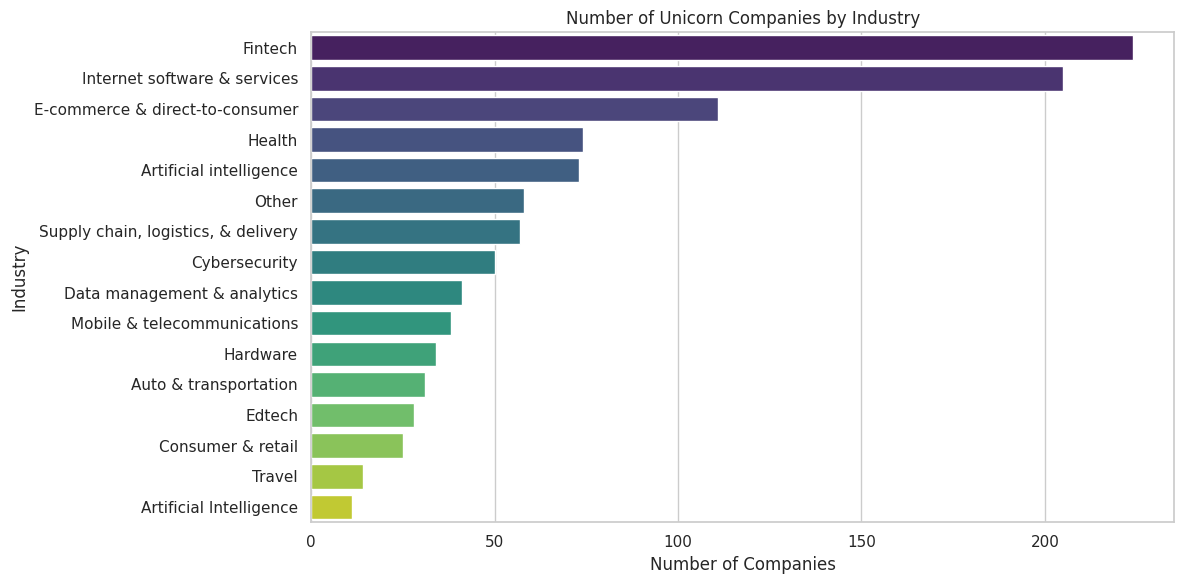

Saved: unicorn_companies_by_industry.png


In [87]:
# Visualize the distribution of unicorn companies by Industry
plt.figure(figsize=(12, 6))
sns.countplot(y='Industry', data=df, order=df['Industry'].value_counts().index, palette='viridis')
plt.title('Number of Unicorn Companies by Industry')
plt.xlabel('Number of Companies')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'unicorn_companies_by_industry.png'))
plt.close()
print("Saved: unicorn_companies_by_industry.png")

In [57]:
# Analyze the distribution of unicorn companies by Country
print("\nDistribution of Unicorn Companies by Country:")
print(df['Country'].value_counts())


Distribution of Unicorn Companies by Country:
Country
United States           562
China                   173
India                    65
United Kingdom           43
Germany                  26
France                   24
Israel                   20
Canada                   19
Brazil                   16
Singapore                12
South Korea              12
Australia                 8
Hong Kong                 6
Sweden                    6
Indonesia                 6
Netherlands               6
Mexico                    6
Ireland                   5
Japan                     5
Switzerland               5
Norway                    4
Finland                   4
Belgium                   3
Spain                     3
Turkey                    3
United Arab Emirates      3
Chile                     2
Estonia                   2
Austria                   2
Denmark                   2
Philippines               2
Vietnam                   2
Colombia                  2
South Africa         

/tmp/ipykernel_5877/2665922850.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Country', data=df, order=df['Country'].value_counts().index, palette='viridis')


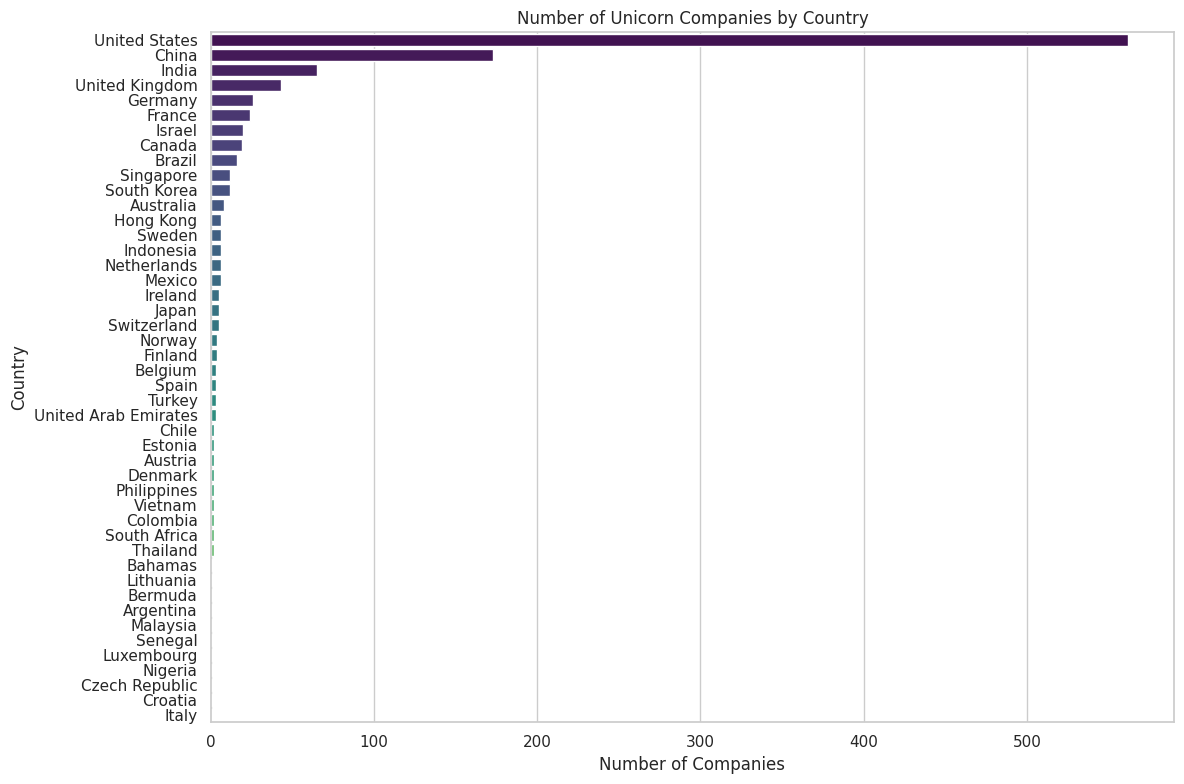

Saved: unicorn_companies_by_country.png


In [88]:
# Visualize the distribution of unicorn companies by Country
plt.figure(figsize=(12, 8))
sns.countplot(y='Country', data=df, order=df['Country'].value_counts().index, palette='viridis')
plt.title('Number of Unicorn Companies by Country')
plt.xlabel('Number of Companies')
plt.ylabel('Country')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'unicorn_companies_by_country.png'))
plt.close()
print("Saved: unicorn_companies_by_country.png")

In [59]:
# Analyze the distribution of unicorn companies by Continent
print("\nDistribution of Unicorn Companies by Continent:")
print(df['Continent'].value_counts())


Distribution of Unicorn Companies by Continent:
Continent
North America    589
Asia             310
Europe           143
South America     21
Oceania            8
Africa             3
Name: count, dtype: int64


/tmp/ipykernel_5877/2088789432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Continent', data=df, order=df['Continent'].value_counts().index, palette='viridis')


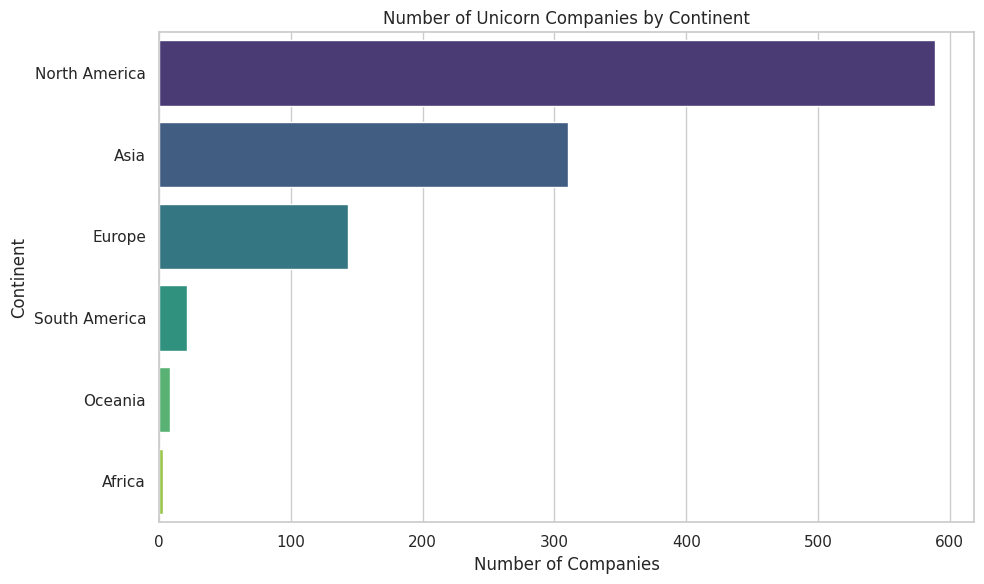

Saved: unicorn_companies_by_continent.png


In [89]:
# Visualize the distribution of unicorn companies by Continent
plt.figure(figsize=(10, 6))
sns.countplot(y='Continent', data=df, order=df['Continent'].value_counts().index, palette='viridis')
plt.title('Number of Unicorn Companies by Continent')
plt.xlabel('Number of Companies')
plt.ylabel('Continent')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'unicorn_companies_by_continent.png'))
plt.close()
print("Saved: unicorn_companies_by_continent.png")

### Growth of Unicorn Companies Over Time

In [61]:
# Extract the year from 'Date Joined'
df['Year Joined'] = df['Date Joined'].dt.year

# Group by 'Year Joined' and count the number of companies
year_joined_counts = df['Year Joined'].value_counts().sort_index()

print("\nNumber of Unicorn Companies by Year Joined:")
print(year_joined_counts)


Number of Unicorn Companies by Year Joined:
Year Joined
2007      1
2011      2
2012      4
2013      3
2014     13
2015     35
2016     21
2017     44
2018    103
2019    104
2020    108
2021    520
2022    116
Name: count, dtype: int64


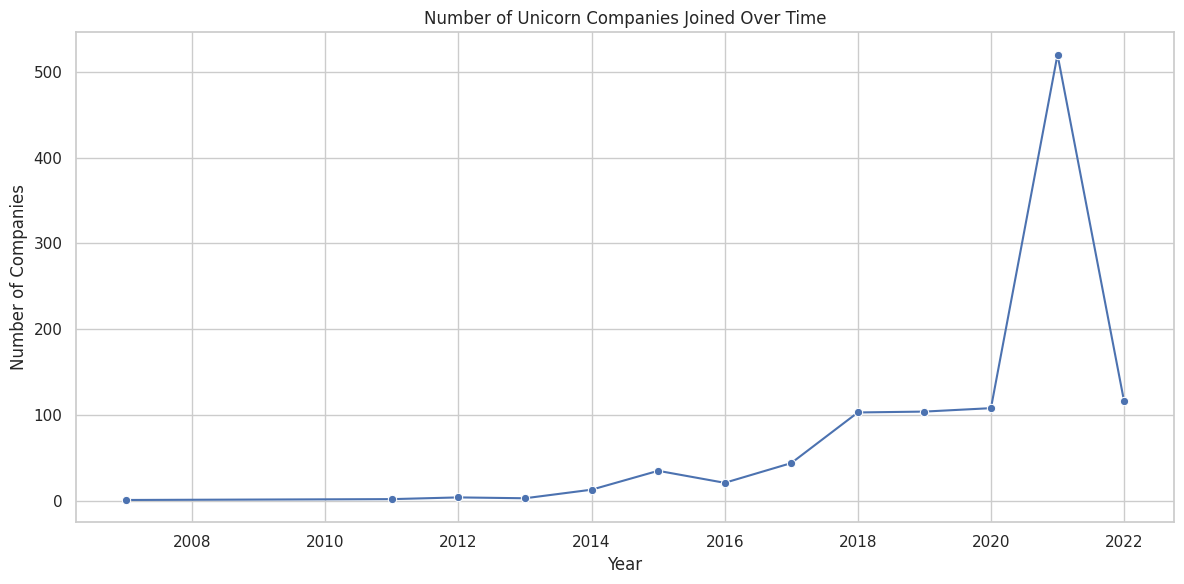

Saved: unicorn_companies_joined_over_time.png


In [90]:
# Visualize the number of unicorn companies by 'Year Joined'
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_joined_counts.index, y=year_joined_counts.values, marker='o')
plt.title('Number of Unicorn Companies Joined Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Companies')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'unicorn_companies_joined_over_time.png'))
plt.close()
print("Saved: unicorn_companies_joined_over_time.png")

In [63]:
# Group by 'Year Founded' and count the number of companies
year_founded_counts = df['Year Founded'].value_counts().sort_index()

print("\nNumber of Unicorn Companies by Year Founded:")
print(year_founded_counts)


Number of Unicorn Companies by Year Founded:
Year Founded
1919      1
1979      1
1984      1
1990      1
1991      1
1992      1
1993      1
1994      2
1995      2
1996      1
1997      1
1998      5
1999      8
2000     11
2001      9
2002      4
2003      8
2004      8
2005     14
2006     15
2007     24
2008     27
2009     34
2010     40
2011     82
2012     95
2013     87
2014    109
2015    155
2016    110
2017     74
2018     61
2019     45
2020     25
2021     11
Name: count, dtype: int64


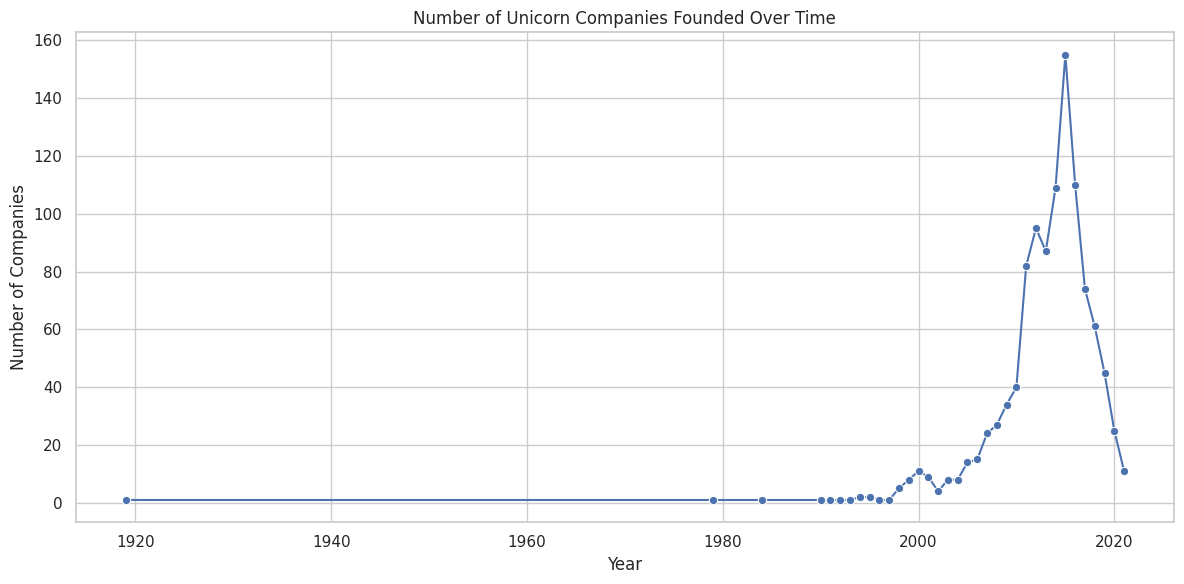

Saved: unicorn_companies_founded_over_time.png


In [91]:
# Visualize the number of unicorn companies by 'Year Founded'
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_founded_counts.index, y=year_founded_counts.values, marker='o')
plt.title('Number of Unicorn Companies Founded Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Companies')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'unicorn_companies_founded_over_time.png'))
plt.close()
print("Saved: unicorn_companies_founded_over_time.png")

### Cleaning and Converting 'Valuation' to Billions

In [76]:
def convert_valuation_to_billions(valuation_str):
    """Converts a valuation string (e.g., '$180B', '$500M') to a float in billions."""
    valuation_str = str(valuation_str).replace('$', '').strip()

    if valuation_str == 'Unknown':
        return np.nan  # Handle 'Unknown' values by converting them to NaN

    if valuation_str.endswith('B'):
        return float(valuation_str.replace('B', ''))
    elif valuation_str.endswith('M'):
        return float(valuation_str.replace('M', '')) / 1000  # Convert millions to billions
    else:
        try:
            # Assume it's already in dollars if no B or M, convert to billions
            return float(valuation_str) / 1000000000
        except ValueError:
            # Handle any other unexpected non-numeric strings
            return np.nan

df['Valuation_B'] = df['Valuation'].apply(convert_valuation_to_billions)

print("Original 'Valuation' column:")
print(df[['Valuation', 'Valuation_B']].head())
print("\nData types after conversion:")
df.info()

Original 'Valuation' column:
  Valuation  Valuation_B
0     $180B        180.0
1     $100B        100.0
2     $100B        100.0
3      $95B         95.0
4      $46B         46.0

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1074 non-null   object        
 5   Country           1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1074 non-null   object        
 10  Year Joined       1074 non-null

In [77]:
# Display descriptive statistics for the new 'Valuation_B' column
print("\nDescriptive statistics for 'Valuation_B' (in Billions):")
print(df['Valuation_B'].describe())


Descriptive statistics for 'Valuation_B' (in Billions):
count    1074.000000
mean        3.455307
std         8.547022
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       180.000000
Name: Valuation_B, dtype: float64


In [69]:
industry_counts = df['Industry'].value_counts()
print("\nNumber of Companies by Industry:")
print(industry_counts)


Number of Companies by Industry:
Industry
Fintech                                224
Internet software & services           205
E-commerce & direct-to-consumer        111
Health                                  74
Artificial intelligence                 73
Other                                   58
Supply chain, logistics, & delivery     57
Cybersecurity                           50
Data management & analytics             41
Mobile & telecommunications             38
Hardware                                34
Auto & transportation                   31
Edtech                                  28
Consumer & retail                       25
Travel                                  14
Artificial Intelligence                 11
Name: count, dtype: int64


### Top 10 Industries by Number of Unicorn Companies

In [70]:
# Get the top 10 industries by count
top_10_industries = industry_counts.head(10)

print("\nTop 10 Industries by Number of Unicorn Companies:")
print(top_10_industries)


Top 10 Industries by Number of Unicorn Companies:
Industry
Fintech                                224
Internet software & services           205
E-commerce & direct-to-consumer        111
Health                                  74
Artificial intelligence                 73
Other                                   58
Supply chain, logistics, & delivery     57
Cybersecurity                           50
Data management & analytics             41
Mobile & telecommunications             38
Name: count, dtype: int64


/tmp/ipykernel_5877/1089669562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_industries.values, y=top_10_industries.index, palette='viridis')


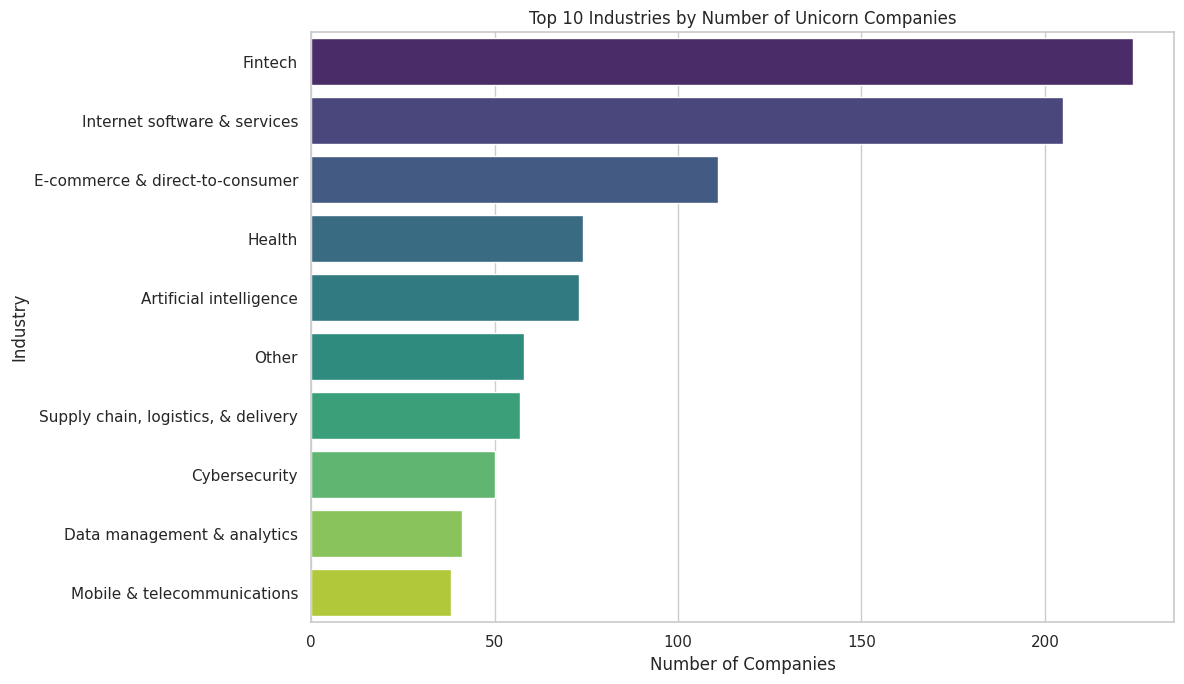

Saved: top_10_industries.png


In [92]:
# Visualize the top 10 industries
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_industries.values, y=top_10_industries.index, palette='viridis')
plt.title('Top 10 Industries by Number of Unicorn Companies')
plt.xlabel('Number of Companies')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'top_10_industries.png'))
plt.close()
print("Saved: top_10_industries.png")

### Average Valuation per Industry

In [72]:
# Calculate the average valuation per industry
average_valuation_per_industry = df.groupby('Industry')['Valuation_B'].mean().sort_values(ascending=False)

print("\nAverage Valuation per Industry (in Billions):")
print(average_valuation_per_industry)


Average Valuation per Industry (in Billions):
Industry
Artificial intelligence                4.945205
Other                                  4.344828
Consumer & retail                      4.240000
Fintech                                3.937500
E-commerce & direct-to-consumer        3.837838
Edtech                                 3.571429
Data management & analytics            3.317073
Travel                                 3.285714
Auto & transportation                  3.193548
Supply chain, logistics, & delivery    3.105263
Hardware                               2.911765
Internet software & services           2.902439
Health                                 2.675676
Cybersecurity                          2.580000
Mobile & telecommunications            2.342105
Artificial Intelligence                1.454545
Name: Valuation_B, dtype: float64


/tmp/ipykernel_5877/4223810621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_valuation_per_industry.values, y=average_valuation_per_industry.index, palette='magma')


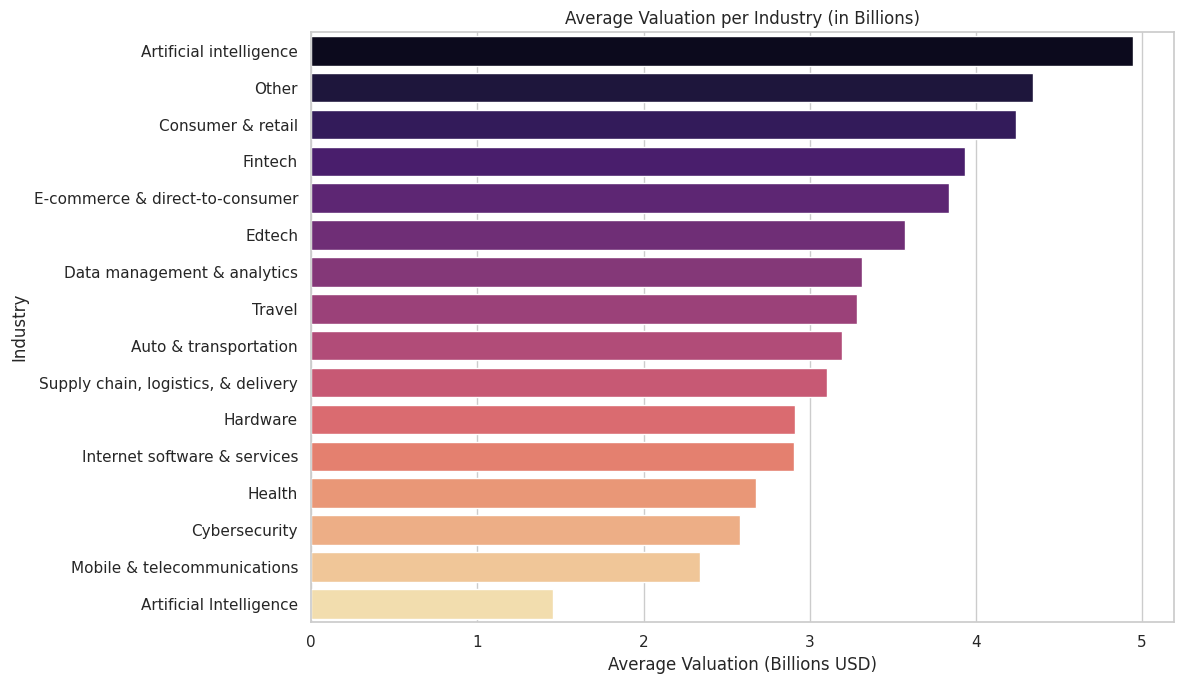

Saved: average_valuation_per_industry.png


In [93]:
# Visualize the average valuation per industry
plt.figure(figsize=(12, 7))
sns.barplot(x=average_valuation_per_industry.values, y=average_valuation_per_industry.index, palette='magma')
plt.title('Average Valuation per Industry (in Billions)')
plt.xlabel('Average Valuation (Billions USD)')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'average_valuation_per_industry.png'))
plt.close()
print("Saved: average_valuation_per_industry.png")

### Cleaning and Converting 'Funding' to Billions

In [79]:
# Reuse the conversion function for 'Funding'
df['Funding_B'] = df['Funding'].apply(convert_valuation_to_billions)

print("Original 'Funding' column:")
print(df[['Funding', 'Funding_B']].head())
print("\nData types after funding conversion:")
df.info()

Original 'Funding' column:
  Funding  Funding_B
0     $8B        8.0
1     $7B        7.0
2     $2B        2.0
3     $2B        2.0
4     $4B        4.0

Data types after funding conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1074 non-null   object        
 5   Country           1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1074 non-null   object        
 10  Year Joined       1074 non-null   int32         


### Scatter Plot of Funding vs. Valuation

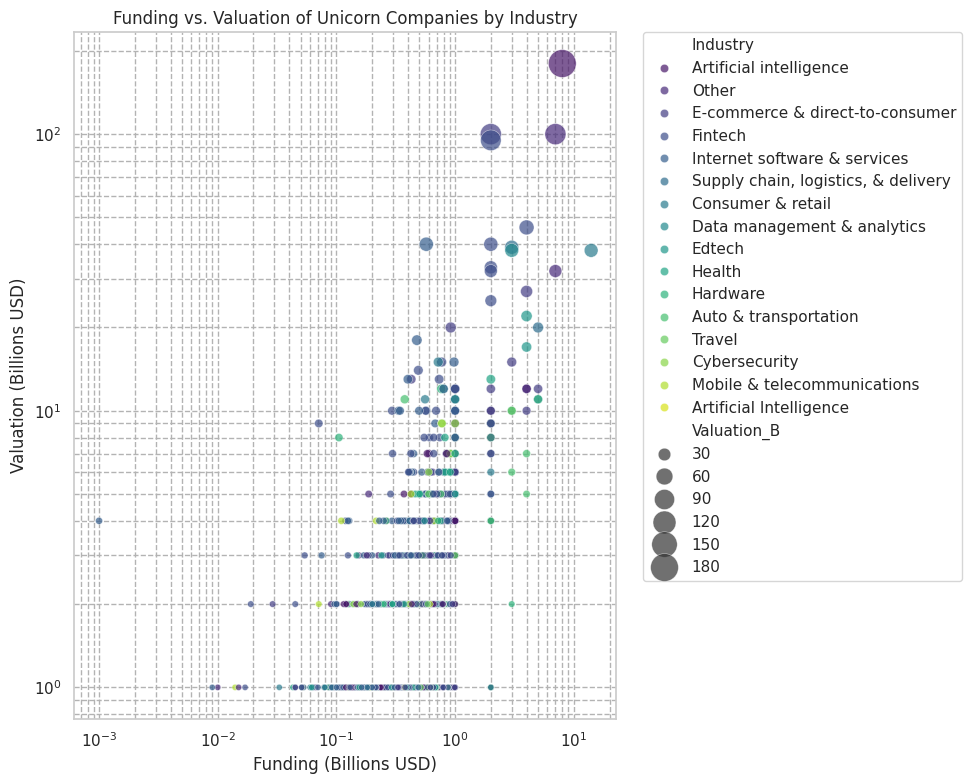

Saved: funding_vs_valuation_scatter.png


In [94]:
# Create a scatter plot of Funding (in Billions) vs. Valuation (in Billions)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Funding_B', y='Valuation_B', data=df, hue='Industry', size='Valuation_B', sizes=(20, 400), palette='viridis', alpha=0.7)
plt.title('Funding vs. Valuation of Unicorn Companies by Industry')
plt.xlabel('Funding (Billions USD)')
plt.ylabel('Valuation (Billions USD)')
plt.xscale('log') # Use log scale for better visualization if values span a wide range
plt.yscale('log') # Use log scale for better visualization if values span a wide range
plt.grid(True, which='both', ls='--', c='0.7')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'funding_vs_valuation_scatter.png'))
plt.close()
print("Saved: funding_vs_valuation_scatter.png")

### Multivariate Analysis: Correlation Matrix

In [81]:
# Select numerical columns for correlation analysis
numerical_cols = ['Year Founded', 'Year Joined', 'Valuation_B', 'Funding_B']
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Year Founded,Year Joined,Valuation_B,Funding_B
Year Founded,1.000000,0.353961,-0.074395,-0.080582
Year Joined,0.353961,1.000000,-0.219981,-0.291847
Valuation_B,-0.074395,-0.219981,1.000000,0.598384
Funding_B,-0.080582,-0.291847,0.598384,1.000000


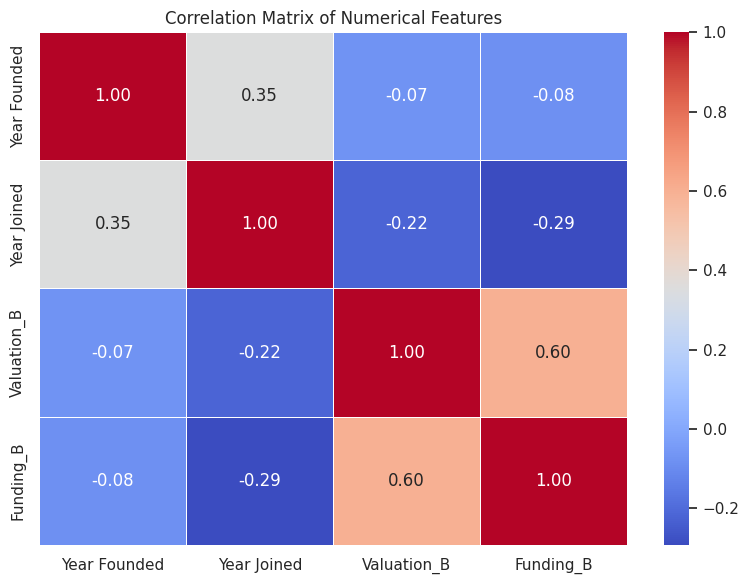

Saved: correlation_matrix_heatmap.png


In [95]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'correlation_matrix_heatmap.png'))
plt.close()
print("Saved: correlation_matrix_heatmap.png")

### Multivariate Analysis: Pairplot of Numerical Features

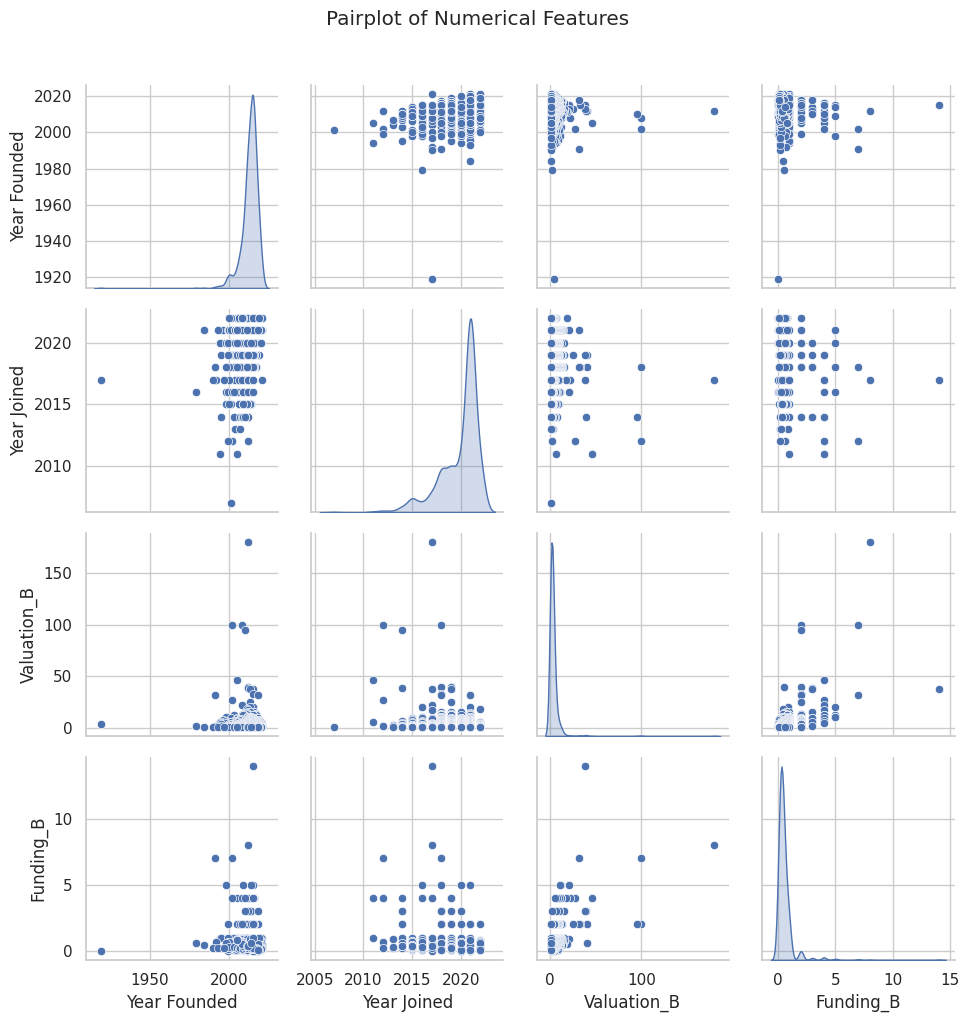

Saved: numerical_features_pairplot.png


In [96]:
# Select numerical columns for the pairplot
numerical_cols_for_pairplot = ['Year Founded', 'Year Joined', 'Valuation_B', 'Funding_B']

# Create a pairplot
sns.pairplot(df[numerical_cols_for_pairplot], diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Adjust suptitle to not overlap
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(graphs_dir, 'numerical_features_pairplot.png'))
plt.close()
print("Saved: numerical_features_pairplot.png")

### Downloading All Graphs

In [84]:
import os
import shutil

# Create a directory to save the graphs
graphs_dir = 'graphs'
if not os.path.exists(graphs_dir):
    os.makedirs(graphs_dir)
print(f"Created directory: {graphs_dir}")

Created directory: graphs


In [97]:
# To create a zip file of all graphs for easy download
zip_filename = 'graphs'
shutil.make_archive(zip_filename, 'zip', graphs_dir)
print(f"All graphs saved to '{graphs_dir}' and zipped into '{zip_filename}.zip'")
print("You can now download the 'graphs.zip' file from the Colab file browser.")

All graphs saved to 'graphs' and zipped into 'graphs.zip'
You can now download the 'graphs.zip' file from the Colab file browser.
